# Depth, Stability, and Scaling

This notebook is about **making deep nets work**:
- Why deep MLPs fail (vanishing/exploding gradients)
- Fixes: initialization, normalization, residuals, gradient clipping
- Overfitting vs underfitting
- Diagnostics: activation stats, gradient norms, loss curves

We use a synthetic dataset: **two moons** (nonlinear boundary). Implemented without sklearn.


## Setup

In [1]:
import math
import random
from dataclasses import dataclass
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## 1) Reproducibility

In [2]:
def seed_everything(seed: int = 0, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True, warn_only=True)
    else:
        torch.backends.cudnn.benchmark = True

seed_everything(42, deterministic=True)


## 2) Two-moons data generator (NumPy)

X,y: (2000, 2) (2000, 1) pos_rate= 0.5


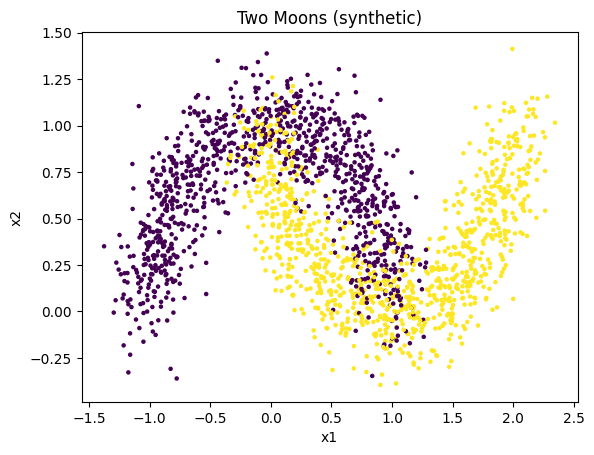

In [3]:
def make_two_moons(n_samples: int = 2000, noise: float = 0.12, seed: int = 0):
    rng = np.random.default_rng(seed)
    n1 = n_samples // 2
    n2 = n_samples - n1

    t1 = rng.uniform(0, math.pi, size=n1)
    x1 = np.c_[np.cos(t1), np.sin(t1)]

    t2 = rng.uniform(0, math.pi, size=n2)
    x2 = np.c_[1 - np.cos(t2), 1 - np.sin(t2)]

    X = np.vstack([x1, x2]).astype(np.float32)
    y = np.hstack([np.zeros(n1), np.ones(n2)]).astype(np.float32)

    X += rng.normal(scale=noise, size=X.shape).astype(np.float32)

    idx = rng.permutation(n_samples)
    return X[idx], y[idx][:, None]

X, y = make_two_moons(n_samples=2000, noise=0.15, seed=1)
print("X,y:", X.shape, y.shape, "pos_rate=", y.mean())

plt.figure()
plt.scatter(X[:,0], X[:,1], c=y[:,0], s=5)
plt.title("Two Moons (synthetic)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


## 3) Train/val split + Dataset/DataLoader

In [4]:
def train_val_split(X, y, val_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    idx = rng.permutation(n)
    n_val = int(n * val_ratio)
    val_idx = idx[:n_val]
    tr_idx = idx[n_val:]
    return X[tr_idx], y[tr_idx], X[val_idx], y[val_idx]

Xtr, ytr, Xva, yva = train_val_split(X, y, val_ratio=0.2, seed=2)

class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i): return self.X[i], self.y[i]

tr_ds = NumpyDataset(Xtr, ytr)
va_ds = NumpyDataset(Xva, yva)

tr_dl = DataLoader(tr_ds, batch_size=128, shuffle=True)
va_dl = DataLoader(va_ds, batch_size=256, shuffle=False)

xb, yb = next(iter(tr_dl))
print("batch:", xb.shape, yb.shape)


batch: torch.Size([128, 2]) torch.Size([128, 1])


## 4) Config

In [5]:
@dataclass
class Config:
    seed: int = 42
    depth: int = 12
    width: int = 64
    activation: str = "relu"      # relu or tanh
    use_batchnorm: bool = False
    use_layernorm: bool = False
    use_residual: bool = False
    init: str = "naive"           # naive, xavier, kaiming
    lr: float = 1e-3
    weight_decay: float = 0.0
    epochs: int = 60
    grad_clip_norm: float = 0.0
    use_dropout: bool = False
    dropout_p: float = 0.1

cfg = Config()
cfg


Config(seed=42, depth=12, width=64, activation='relu', use_batchnorm=False, use_layernorm=False, use_residual=False, init='naive', lr=0.001, weight_decay=0.0, epochs=60, grad_clip_norm=0.0, use_dropout=False, dropout_p=0.1)

## 5) Deep MLP builder

In [6]:
def get_activation(name: str):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    raise ValueError("activation must be 'relu' or 'tanh'")

class ResidualBlock(nn.Module):
    def __init__(self, dim: int, activation: nn.Module, norm_ctor, dropout_p: float = 0.0):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.activation = activation
        self.norm1 = norm_ctor(dim) if norm_ctor is not None else None
        self.norm2 = norm_ctor(dim) if norm_ctor is not None else None
        self.drop = nn.Dropout(dropout_p) if dropout_p and dropout_p > 0 else nn.Identity()

    def forward(self, x):
        h = self.fc1(x)
        if self.norm1 is not None:
            h = self.norm1(h)
        h = self.activation(h)
        h = self.drop(h)
        h = self.fc2(h)
        if self.norm2 is not None:
            h = self.norm2(h)
        return x + h

class DeepMLP(nn.Module):
    def __init__(self, in_dim: int, width: int, depth: int, activation: str,
                 use_batchnorm: bool, use_layernorm: bool, use_residual: bool,
                 use_dropout: bool, dropout_p: float):
        super().__init__()
        act = get_activation(activation)

        norm_ctor = None
        if use_batchnorm and use_layernorm:
            raise ValueError("Choose BatchNorm OR LayerNorm, not both.")
        if use_batchnorm:
            norm_ctor = nn.BatchNorm1d
        if use_layernorm:
            norm_ctor = nn.LayerNorm

        layers: List[nn.Module] = []
        layers.append(nn.Linear(in_dim, width))
        if norm_ctor is not None:
            layers.append(norm_ctor(width))
        layers.append(act)
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))

        if use_residual:
            for _ in range(depth - 1):
                layers.append(ResidualBlock(width, act, norm_ctor, dropout_p if use_dropout else 0.0))
                layers.append(act)
        else:
            for _ in range(depth - 1):
                layers.append(nn.Linear(width, width))
                if norm_ctor is not None:
                    layers.append(norm_ctor(width))
                layers.append(act)
                if use_dropout:
                    layers.append(nn.Dropout(dropout_p))

        layers.append(nn.Linear(width, 1))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def init_model(model: nn.Module, init: str):
    init = init.lower()
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init == "naive":
                pass
            elif init == "xavier":
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            elif init == "kaiming":
                nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)
            else:
                raise ValueError("init must be naive/xavier/kaiming")
    return model


## 6) Diagnostics: activation stats + grad norm

In [7]:
@torch.no_grad()
def accuracy_from_logits(logits, y):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).to(y.dtype)
    return (preds == y).float().mean().item()

def total_grad_norm(model: nn.Module) -> float:
    s = 0.0
    for p in model.parameters():
        if p.grad is None:
            continue
        s += (p.grad.detach()**2).sum().item()
    return float(s ** 0.5)

class ActivationStats:
    def __init__(self, every_n_linear: int = 4):
        self.every_n_linear = every_n_linear
        self.handles = []
        self.stats = {}  # name -> list of (mean,std,min,max)

    def _hook(self, name):
        def fn(module, inp, out):
            with torch.no_grad():
                t = out.detach()
                self.stats.setdefault(name, []).append((
                    float(t.mean().item()),
                    float(t.std().item()),
                    float(t.min().item()),
                    float(t.max().item()),
                ))
        return fn

    def attach(self, model: nn.Module):
        self.detach()
        self.stats = {}
        k = 0
        for name, m in model.named_modules():
            if isinstance(m, nn.Linear):
                k += 1
                if k == 1 or (k % self.every_n_linear == 0):
                    self.handles.append(m.register_forward_hook(self._hook(name)))

    def detach(self):
        for h in self.handles:
            h.remove()
        self.handles = []


## 7) Train function (swap stability tricks via config)

In [8]:
def run_train(cfg: Config):
    seed_everything(cfg.seed, deterministic=True)

    model = DeepMLP(
        in_dim=2, width=cfg.width, depth=cfg.depth,
        activation=cfg.activation,
        use_batchnorm=cfg.use_batchnorm,
        use_layernorm=cfg.use_layernorm,
        use_residual=cfg.use_residual,
        use_dropout=cfg.use_dropout,
        dropout_p=cfg.dropout_p
    ).to(device)
    model = init_model(model, cfg.init)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    act_stats = ActivationStats(every_n_linear=4)
    act_stats.attach(model)

    history = {"tr_loss": [], "tr_acc": [], "va_loss": [], "va_acc": [], "grad_norm": []}

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        tr_loss = 0.0
        tr_acc = 0.0
        n = 0
        act_stats.stats = {}

        for xb, yb in tr_dl:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            if cfg.grad_clip_norm and cfg.grad_clip_norm > 0:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.grad_clip_norm)

            history["grad_norm"].append(total_grad_norm(model))
            optimizer.step()

            tr_loss += loss.item() * xb.size(0)
            tr_acc += accuracy_from_logits(logits.detach(), yb) * xb.size(0)
            n += xb.size(0)

        tr_loss /= n
        tr_acc /= n

        model.eval()
        va_loss = 0.0
        va_acc = 0.0
        n2 = 0
        with torch.no_grad():
            for xb, yb in va_dl:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                va_loss += loss.item() * xb.size(0)
                va_acc += accuracy_from_logits(logits, yb) * xb.size(0)
                n2 += xb.size(0)

        va_loss /= n2
        va_acc /= n2

        history["tr_loss"].append(tr_loss)
        history["tr_acc"].append(tr_acc)
        history["va_loss"].append(va_loss)
        history["va_acc"].append(va_acc)

        if epoch in (1,2,3) or epoch % 10 == 0 or epoch == cfg.epochs:
            snap = None
            for k, v in act_stats.stats.items():
                if v:
                    snap = (k, v[-1])
                    break
            snap_str = ""
            if snap is not None:
                k, (mu, sd, mn, mx) = snap
                snap_str = f" | act@{k}: mean={mu:.3f} std={sd:.3f} min={mn:.3f} max={mx:.3f}"
            print(f"epoch={epoch:03d} tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f} va_loss={va_loss:.4f} va_acc={va_acc:.3f}{snap_str}")

    act_stats.detach()
    return model, history


## 8) Experiment A — Deep baseline (often unstable)

Deep ReLU MLP, no norms, no residual, naive init, no clipping.


/home/pritesh-jha/projects/research/.venv/lib/python3.12/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return F.linear(input, self.weight, self.bias)
/home/pritesh-jha/projects/research/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(

epoch=001 tr_loss=0.6932 tr_acc=0.507 va_loss=0.6944 va_acc=0.473 | act@net.0: mean=-0.032 std=0.630 min=-2.295 max=2.264
epoch=002 tr_loss=0.6931 tr_acc=0.507 va_loss=0.6937 va_acc=0.473 | act@net.0: mean=-0.032 std=0.630 min=-2.295 max=2.264
epoch=003 tr_loss=0.6932 tr_acc=0.507 va_loss=0.6935 va_acc=0.473 | act@net.0: mean=-0.032 std=0.630 min=-2.295 max=2.263
epoch=010 tr_loss=0.6896 tr_acc=0.547 va_loss=0.6611 va_acc=0.790 | act@net.0: mean=-0.021 std=0.637 min=-2.307 max=2.323
epoch=020 tr_loss=0.2470 tr_acc=0.904 va_loss=0.2578 va_acc=0.885 | act@net.0: mean=-0.021 std=0.639 min=-2.375 max=2.345
epoch=030 tr_loss=0.2250 tr_acc=0.905 va_loss=0.2345 va_acc=0.895 | act@net.0: mean=-0.017 std=0.638 min=-2.375 max=2.334
epoch=040 tr_loss=0.2144 tr_acc=0.904 va_loss=0.2285 va_acc=0.888 | act@net.0: mean=-0.021 std=0.639 min=-2.375 max=2.334
epoch=050 tr_loss=0.2207 tr_acc=0.896 va_loss=0.2273 va_acc=0.885 | act@net.0: mean=-0.023 std=0.639 min=-2.375 max=2.318
epoch=060 tr_loss=0.2050

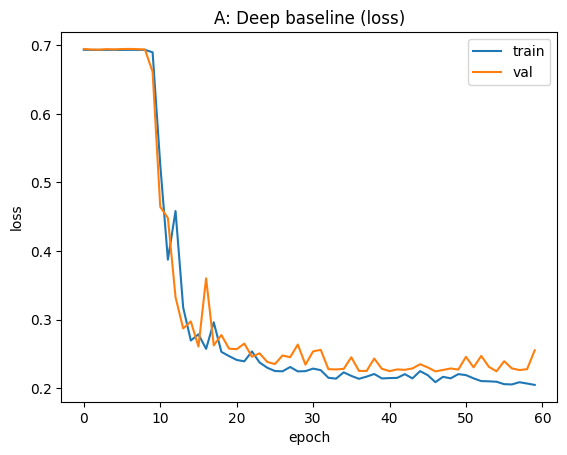

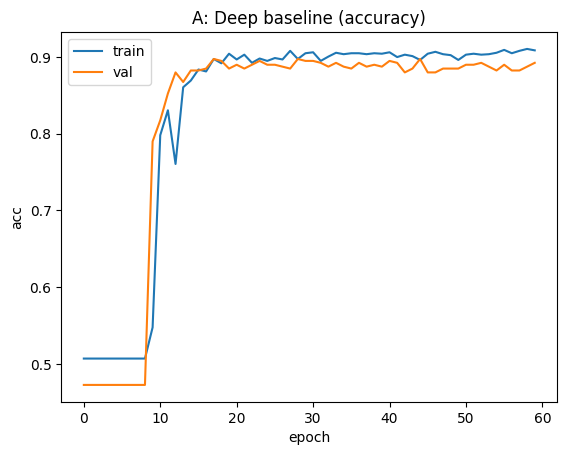

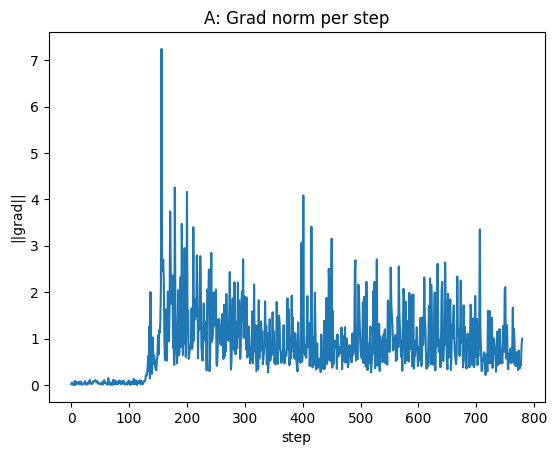

In [9]:
cfgA = Config(depth=20, width=64, activation="relu",
             use_batchnorm=False, use_layernorm=False, use_residual=False,
             init="naive", lr=1e-3, epochs=60, grad_clip_norm=0.0,
             use_dropout=False)

modelA, histA = run_train(cfgA)

plt.figure()
plt.plot(histA["tr_loss"], label="train")
plt.plot(histA["va_loss"], label="val")
plt.title("A: Deep baseline (loss)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

plt.figure()
plt.plot(histA["tr_acc"], label="train")
plt.plot(histA["va_acc"], label="val")
plt.title("A: Deep baseline (accuracy)")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend(); plt.show()

plt.figure()
plt.plot(histA["grad_norm"])
plt.title("A: Grad norm per step")
plt.xlabel("step"); plt.ylabel("||grad||"); plt.show()


## 9) Experiment B — Kaiming init + gradient clipping

epoch=001 tr_loss=0.5362 tr_acc=0.720 va_loss=0.4585 va_acc=0.768 | act@net.0: mean=-0.046 std=1.279 min=-4.401 max=4.713
epoch=002 tr_loss=0.4206 tr_acc=0.777 va_loss=0.3950 va_acc=0.783 | act@net.0: mean=-0.046 std=1.279 min=-4.402 max=4.709
epoch=003 tr_loss=0.4147 tr_acc=0.782 va_loss=0.3862 va_acc=0.800 | act@net.0: mean=-0.047 std=1.279 min=-4.401 max=4.703
epoch=010 tr_loss=0.2583 tr_acc=0.887 va_loss=0.2743 va_acc=0.877 | act@net.0: mean=-0.052 std=1.276 min=-4.399 max=4.681
epoch=020 tr_loss=0.2349 tr_acc=0.899 va_loss=0.2541 va_acc=0.880 | act@net.0: mean=-0.059 std=1.273 min=-4.408 max=4.652
epoch=030 tr_loss=0.2227 tr_acc=0.900 va_loss=0.2478 va_acc=0.885 | act@net.0: mean=-0.062 std=1.271 min=-4.420 max=4.637
epoch=040 tr_loss=0.2334 tr_acc=0.896 va_loss=0.2691 va_acc=0.882 | act@net.0: mean=-0.066 std=1.269 min=-4.428 max=4.622
epoch=050 tr_loss=0.2130 tr_acc=0.901 va_loss=0.2535 va_acc=0.880 | act@net.0: mean=-0.068 std=1.268 min=-4.440 max=4.599
epoch=060 tr_loss=0.2099

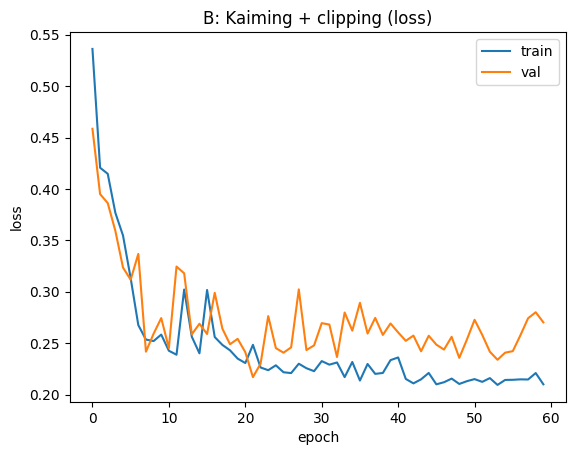

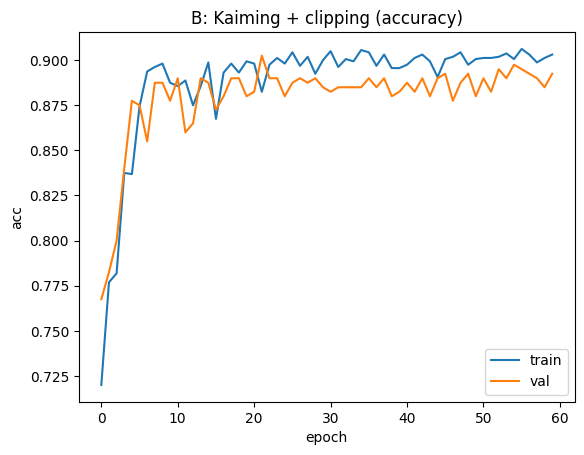

In [10]:
cfgB = Config(depth=20, width=64, activation="relu",
             use_batchnorm=False, use_layernorm=False, use_residual=False,
             init="kaiming", lr=1e-3, epochs=60, grad_clip_norm=1.0,
             use_dropout=False)

modelB, histB = run_train(cfgB)

plt.figure()
plt.plot(histB["tr_loss"], label="train")
plt.plot(histB["va_loss"], label="val")
plt.title("B: Kaiming + clipping (loss)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

plt.figure()
plt.plot(histB["tr_acc"], label="train")
plt.plot(histB["va_acc"], label="val")
plt.title("B: Kaiming + clipping (accuracy)")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend(); plt.show()


## 10) Experiment C — Add LayerNorm

epoch=001 tr_loss=0.5705 tr_acc=0.729 va_loss=0.4613 va_acc=0.770 | act@net.0: mean=-0.046 std=1.280 min=-4.399 max=4.701
epoch=002 tr_loss=0.4709 tr_acc=0.755 va_loss=0.4716 va_acc=0.765 | act@net.0: mean=-0.046 std=1.279 min=-4.400 max=4.697
epoch=003 tr_loss=0.4699 tr_acc=0.763 va_loss=0.4485 va_acc=0.782 | act@net.0: mean=-0.046 std=1.279 min=-4.399 max=4.703
epoch=010 tr_loss=0.3714 tr_acc=0.851 va_loss=0.3600 va_acc=0.850 | act@net.0: mean=-0.036 std=1.270 min=-4.364 max=4.712
epoch=020 tr_loss=0.2988 tr_acc=0.874 va_loss=0.3254 va_acc=0.882 | act@net.0: mean=-0.029 std=1.261 min=-4.328 max=4.722
epoch=030 tr_loss=0.2534 tr_acc=0.892 va_loss=0.2825 va_acc=0.887 | act@net.0: mean=-0.025 std=1.255 min=-4.312 max=4.735
epoch=040 tr_loss=0.2504 tr_acc=0.890 va_loss=0.2688 va_acc=0.885 | act@net.0: mean=-0.022 std=1.249 min=-4.286 max=4.724
epoch=050 tr_loss=0.2781 tr_acc=0.886 va_loss=0.2445 va_acc=0.883 | act@net.0: mean=-0.019 std=1.244 min=-4.257 max=4.707
epoch=060 tr_loss=0.2111

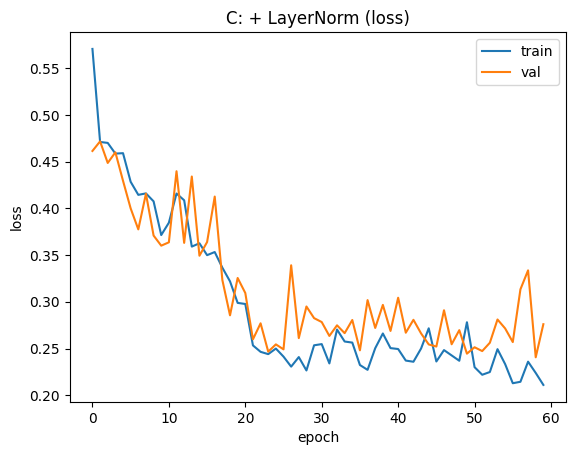

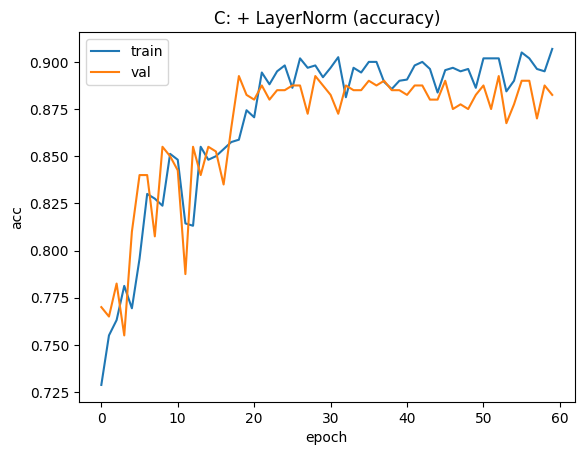

In [11]:
cfgC = Config(depth=20, width=64, activation="relu",
             use_batchnorm=False, use_layernorm=True, use_residual=False,
             init="kaiming", lr=1e-3, epochs=60, grad_clip_norm=1.0,
             use_dropout=False)

modelC, histC = run_train(cfgC)

plt.figure()
plt.plot(histC["tr_loss"], label="train")
plt.plot(histC["va_loss"], label="val")
plt.title("C: + LayerNorm (loss)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

plt.figure()
plt.plot(histC["tr_acc"], label="train")
plt.plot(histC["va_acc"], label="val")
plt.title("C: + LayerNorm (accuracy)")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend(); plt.show()


## 11) Experiment D — Add Residual connections (with LayerNorm)

epoch=001 tr_loss=1.4554 tr_acc=0.621 va_loss=0.4588 va_acc=0.770 | act@net.0: mean=-0.046 std=1.279 min=-4.385 max=4.741
epoch=002 tr_loss=0.5023 tr_acc=0.731 va_loss=0.4580 va_acc=0.773 | act@net.0: mean=-0.046 std=1.279 min=-4.382 max=4.747
epoch=003 tr_loss=0.4671 tr_acc=0.771 va_loss=0.4756 va_acc=0.755 | act@net.0: mean=-0.047 std=1.281 min=-4.393 max=4.756
epoch=010 tr_loss=0.4045 tr_acc=0.819 va_loss=0.3776 va_acc=0.848 | act@net.0: mean=-0.051 std=1.281 min=-4.391 max=4.743
epoch=020 tr_loss=0.3227 tr_acc=0.861 va_loss=0.3073 va_acc=0.873 | act@net.0: mean=-0.039 std=1.266 min=-4.335 max=4.731
epoch=030 tr_loss=0.2531 tr_acc=0.892 va_loss=0.2406 va_acc=0.890 | act@net.0: mean=-0.029 std=1.254 min=-4.285 max=4.719
epoch=040 tr_loss=0.2592 tr_acc=0.876 va_loss=0.3413 va_acc=0.868 | act@net.0: mean=-0.023 std=1.246 min=-4.258 max=4.704
epoch=050 tr_loss=0.2839 tr_acc=0.868 va_loss=0.3491 va_acc=0.865 | act@net.0: mean=-0.018 std=1.240 min=-4.238 max=4.711
epoch=060 tr_loss=0.2227

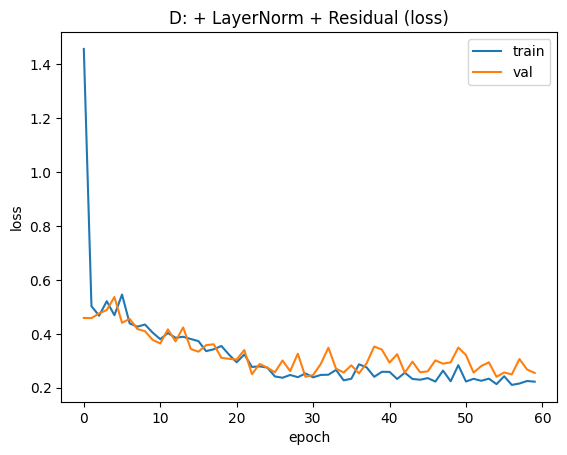

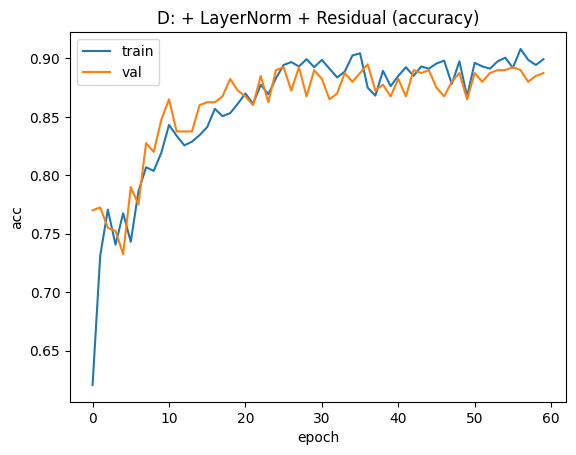

In [12]:
cfgD = Config(depth=20, width=64, activation="relu",
             use_batchnorm=False, use_layernorm=True, use_residual=True,
             init="kaiming", lr=1e-3, epochs=60, grad_clip_norm=1.0,
             use_dropout=False)

modelD, histD = run_train(cfgD)

plt.figure()
plt.plot(histD["tr_loss"], label="train")
plt.plot(histD["va_loss"], label="val")
plt.title("D: + LayerNorm + Residual (loss)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

plt.figure()
plt.plot(histD["tr_acc"], label="train")
plt.plot(histD["va_acc"], label="val")
plt.title("D: + LayerNorm + Residual (accuracy)")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend(); plt.show()


## 12) Overfitting vs underfitting (bigger model + regularization)

epoch=001 tr_loss=1.8503 tr_acc=0.569 va_loss=0.9906 va_acc=0.710 | act@net.0: mean=0.010 std=1.242 min=-4.535 max=4.814
epoch=002 tr_loss=0.8884 tr_acc=0.667 va_loss=0.5547 va_acc=0.767 | act@net.0: mean=0.010 std=1.242 min=-4.536 max=4.813
epoch=003 tr_loss=0.6739 tr_acc=0.703 va_loss=0.5446 va_acc=0.735 | act@net.0: mean=0.010 std=1.242 min=-4.536 max=4.816
epoch=010 tr_loss=0.5181 tr_acc=0.738 va_loss=0.4546 va_acc=0.780 | act@net.0: mean=0.014 std=1.242 min=-4.535 max=4.794
epoch=020 tr_loss=0.4565 tr_acc=0.785 va_loss=0.4531 va_acc=0.810 | act@net.0: mean=0.030 std=1.227 min=-4.451 max=4.810
epoch=030 tr_loss=0.3759 tr_acc=0.835 va_loss=0.3990 va_acc=0.838 | act@net.0: mean=0.053 std=1.199 min=-4.319 max=4.852
epoch=040 tr_loss=0.3354 tr_acc=0.859 va_loss=0.3233 va_acc=0.868 | act@net.0: mean=0.066 std=1.182 min=-4.284 max=4.849
epoch=050 tr_loss=0.2954 tr_acc=0.875 va_loss=0.2461 va_acc=0.883 | act@net.0: mean=0.070 std=1.168 min=-4.266 max=4.821
epoch=060 tr_loss=0.2533 tr_acc=

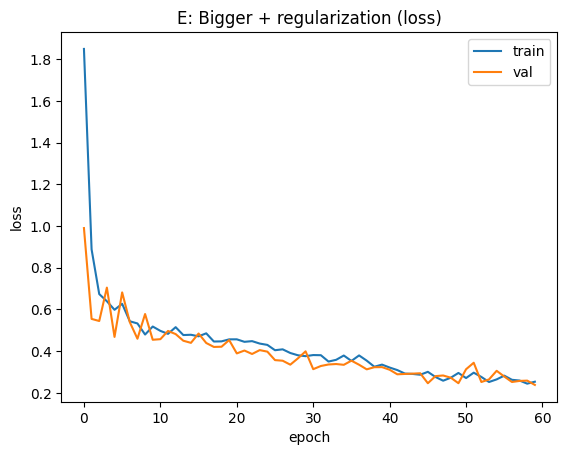

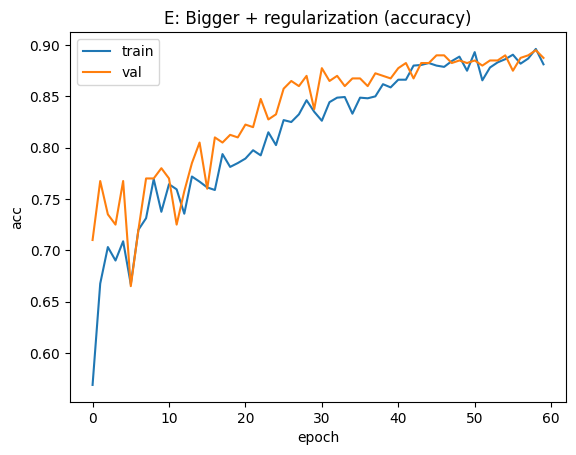

In [13]:
cfgE = Config(depth=10, width=256, activation="relu",
             use_batchnorm=False, use_layernorm=True, use_residual=True,
             init="kaiming", lr=1e-3, epochs=60, grad_clip_norm=1.0,
             use_dropout=True, dropout_p=0.2, weight_decay=1e-3)

modelE, histE = run_train(cfgE)

plt.figure()
plt.plot(histE["tr_loss"], label="train")
plt.plot(histE["va_loss"], label="val")
plt.title("E: Bigger + regularization (loss)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

plt.figure()
plt.plot(histE["tr_acc"], label="train")
plt.plot(histE["va_acc"], label="val")
plt.title("E: Bigger + regularization (accuracy)")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend(); plt.show()


## 13) Decision boundary visualization

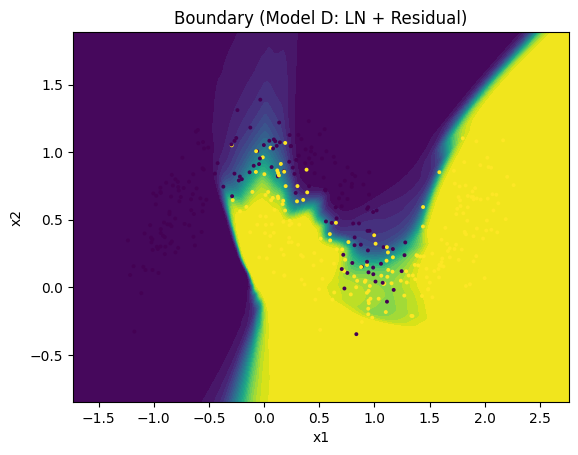

In [14]:
@torch.no_grad()
def plot_boundary(model, X, y, title="Decision boundary"):
    model.eval()

    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5

    xs = np.linspace(x_min, x_max, 300)
    ys = np.linspace(y_min, y_max, 300)
    grid = np.array([[a,b] for a in xs for b in ys], dtype=np.float32)

    logits = model(torch.tensor(grid, device=device))
    probs = torch.sigmoid(logits).cpu().numpy().reshape(len(xs), len(ys))

    plt.figure()
    plt.contourf(xs, ys, probs.T, levels=30)
    plt.scatter(X[:,0], X[:,1], c=y[:,0], s=8, edgecolors="none")
    plt.title(title)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()

plot_boundary(modelD, Xva, yva, title="Boundary (Model D: LN + Residual)")


## Extra (incase you guys wish to experiment more)

- Try `tanh` + Xavier init and compare.
- Increase depth to 40 and see which variants still train.
- Swap AdamW to SGD+momentum and compare.
